In [1]:
import numpy as np
import os

In [2]:
dataset_path = "/kaggle/input/garbage-dataset/garbage_classification"
classes = os.listdir(dataset_path)
print (f"Classes found: {classes}")

Classes found: ['metal', 'Plastic-bag', 'white-glass', 'biological', 'paper', 'battery', 'trash', 'cardboard', 'shoes', 'clothes', 'Bottle']


In [3]:
image_paths, labels = [], []
for label, class_name in enumerate(classes):
    class_dir = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_dir):
        image_paths.append(os.path.join(class_dir, img_name))
        labels.append(label)

In [4]:
import pandas as pd
from sklearn.model_selection import train_test_split
import cv2
import tensorflow as tf
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
from skimage import feature
import numpy as np
import warnings
warnings.filterwarnings('ignore')

2026-01-19 14:27:18.483187: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768832838.705786      47 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768832838.771319      47 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

In [5]:
# Hàm tính HOG features
def compute_hog_features(image_path, resize_size=(128, 128)):
    """
    Tính HOG features từ ảnh
    """
    try:
        # Đọc ảnh
        img = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            return None
        
        # Resize ảnh
        img = cv2.resize(img, resize_size)
        
        # Tính HOG features
        hog_features = feature.hog(img, 
                                    orientations=9,
                                    pixels_per_cell=(8, 8),
                                    cells_per_block=(2, 2),
                                    visualize=False)
        
        return hog_features
    except Exception as e:
        print(f"Lỗi xử lý {image_path}: {e}")
        return None

# Tính HOG features cho tất cả ảnh
print("Đang tính HOG features...")
hog_features_list = []
valid_labels = []
valid_image_paths = []

for idx, (img_path, label) in enumerate(zip(image_paths, labels)):
    if idx % 500 == 0:
        print(f"Đã xử lý {idx}/{len(image_paths)}")
    
    hog_feat = compute_hog_features(img_path)
    if hog_feat is not None:
        hog_features_list.append(hog_feat)
        valid_labels.append(label)
        valid_image_paths.append(img_path) 

# Chuyển thành numpy array
X = np.array(hog_features_list)
y = np.array(valid_labels)

print(f"\nHOG features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"Số lượng class: {len(set(y))}")

Đang tính HOG features...
Đã xử lý 0/15376
Đã xử lý 500/15376
Đã xử lý 1000/15376
Đã xử lý 1500/15376
Đã xử lý 2000/15376
Đã xử lý 2500/15376
Đã xử lý 3000/15376
Đã xử lý 3500/15376
Đã xử lý 4000/15376
Đã xử lý 4500/15376
Đã xử lý 5000/15376
Đã xử lý 5500/15376
Đã xử lý 6000/15376
Đã xử lý 6500/15376
Đã xử lý 7000/15376
Đã xử lý 7500/15376
Đã xử lý 8000/15376
Đã xử lý 8500/15376
Đã xử lý 9000/15376
Đã xử lý 9500/15376
Đã xử lý 10000/15376
Đã xử lý 10500/15376
Đã xử lý 11000/15376
Đã xử lý 11500/15376
Đã xử lý 12000/15376
Đã xử lý 12500/15376
Đã xử lý 13000/15376
Đã xử lý 13500/15376
Đã xử lý 14000/15376
Đã xử lý 14500/15376
Đã xử lý 15000/15376

HOG features shape: (15376, 8100)
Labels shape: (15376,)
Số lượng class: 11


In [6]:
X_train, X_test, y_train, y_test, paths_train, paths_test = train_test_split(
    X, 
    y, 
    valid_image_paths,
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"Feature dimensions: {X_train.shape[1]}")

Training set size: 12300
Test set size: 3076
Feature dimensions: 8100


In [7]:
#  HUẤN LUYỆN SVM

print("HUẤN LUYỆN MÔ HÌNH SVM")

svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_model.fit(X_train, y_train)

# Dự đoán
y_pred_svm = svm_model.predict(X_test)

# Đánh giá
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print(f"\nSVM Accuracy: {svm_accuracy:.4f}")

HUẤN LUYỆN MÔ HÌNH SVM

SVM Accuracy: 0.6934


In [8]:
print(classification_report(y_test, y_pred_svm, target_names=[classes[i] for i in range(len(classes))]))

              precision    recall  f1-score   support

       metal       0.60      0.49      0.54       155
 Plastic-bag       0.51      0.24      0.33       142
 white-glass       0.57      0.56      0.56       155
  biological       0.51      0.31      0.39       197
       paper       0.73      0.67      0.70       212
     battery       0.64      0.78      0.70       189
       trash       0.82      0.57      0.67       139
   cardboard       0.54      0.24      0.33       178
       shoes       0.63      0.73      0.67       396
     clothes       0.78      0.95      0.86      1065
      Bottle       0.64      0.66      0.65       248

    accuracy                           0.69      3076
   macro avg       0.63      0.56      0.58      3076
weighted avg       0.68      0.69      0.67      3076



In [9]:
# ============ HÀM DỰ ĐOÁN TỪ ẢNH MỚI ============
def predict_image(image_path, model, model_name="Model"):
    """
    Dự đoán class của một ảnh mới
    """
    hog_feat = compute_hog_features(image_path)
    if hog_feat is None:
        print("Không thể xử lý ảnh")
        return None
    
    # Reshape để phù hợp với model
    hog_feat = hog_feat.reshape(1, -1)
    
    # Dự đoán
    prediction = model.predict(hog_feat)[0]
    confidence = model.predict_proba(hog_feat).max() if hasattr(model, 'predict_proba') else None
    
    class_name = classes[prediction]
    print(f"\n{model_name} Dự đoán: {class_name}")
    if confidence:
        print(f"Độ tin cậy: {confidence:.4f}")
    
    return class_name

# Test dự đoán trên một vài ảnh từ test set
print("TEST DỰ ĐOÁN TRÊN CÁC ẢNH MỚI")
# Lấy một vài ảnh từ test set
test_indices = np.random.choice(len(X_test), 3, replace=False)

for idx in test_indices:
    img_idx = list(range(len(image_paths)))[np.where((X == X_test[idx]).all(axis=1))[0][0]] if len(np.where((X == X_test[idx]).all(axis=1))[0]) > 0 else None
    if img_idx is not None:
        print(f"\nẢnh: {image_paths[img_idx]}")
        print(f"Class thực tế: {classes[y_test[idx]]}")
        predict_image(image_paths[img_idx], svm_model, "SVM")

TEST DỰ ĐOÁN TRÊN CÁC ẢNH MỚI

Ảnh: /kaggle/input/garbage-dataset/garbage_classification/Bottle/000014_jpg.rf.69996f4e36b9658d54e469b0fcbca514.jpg
Class thực tế: Bottle

SVM Dự đoán: clothes

Ảnh: /kaggle/input/garbage-dataset/garbage_classification/shoes/shoes447.jpg
Class thực tế: shoes

SVM Dự đoán: shoes

Ảnh: /kaggle/input/garbage-dataset/garbage_classification/battery/battery645.jpg
Class thực tế: battery

SVM Dự đoán: battery


HIỂN THỊ ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN (Tổng: 943 ảnh)


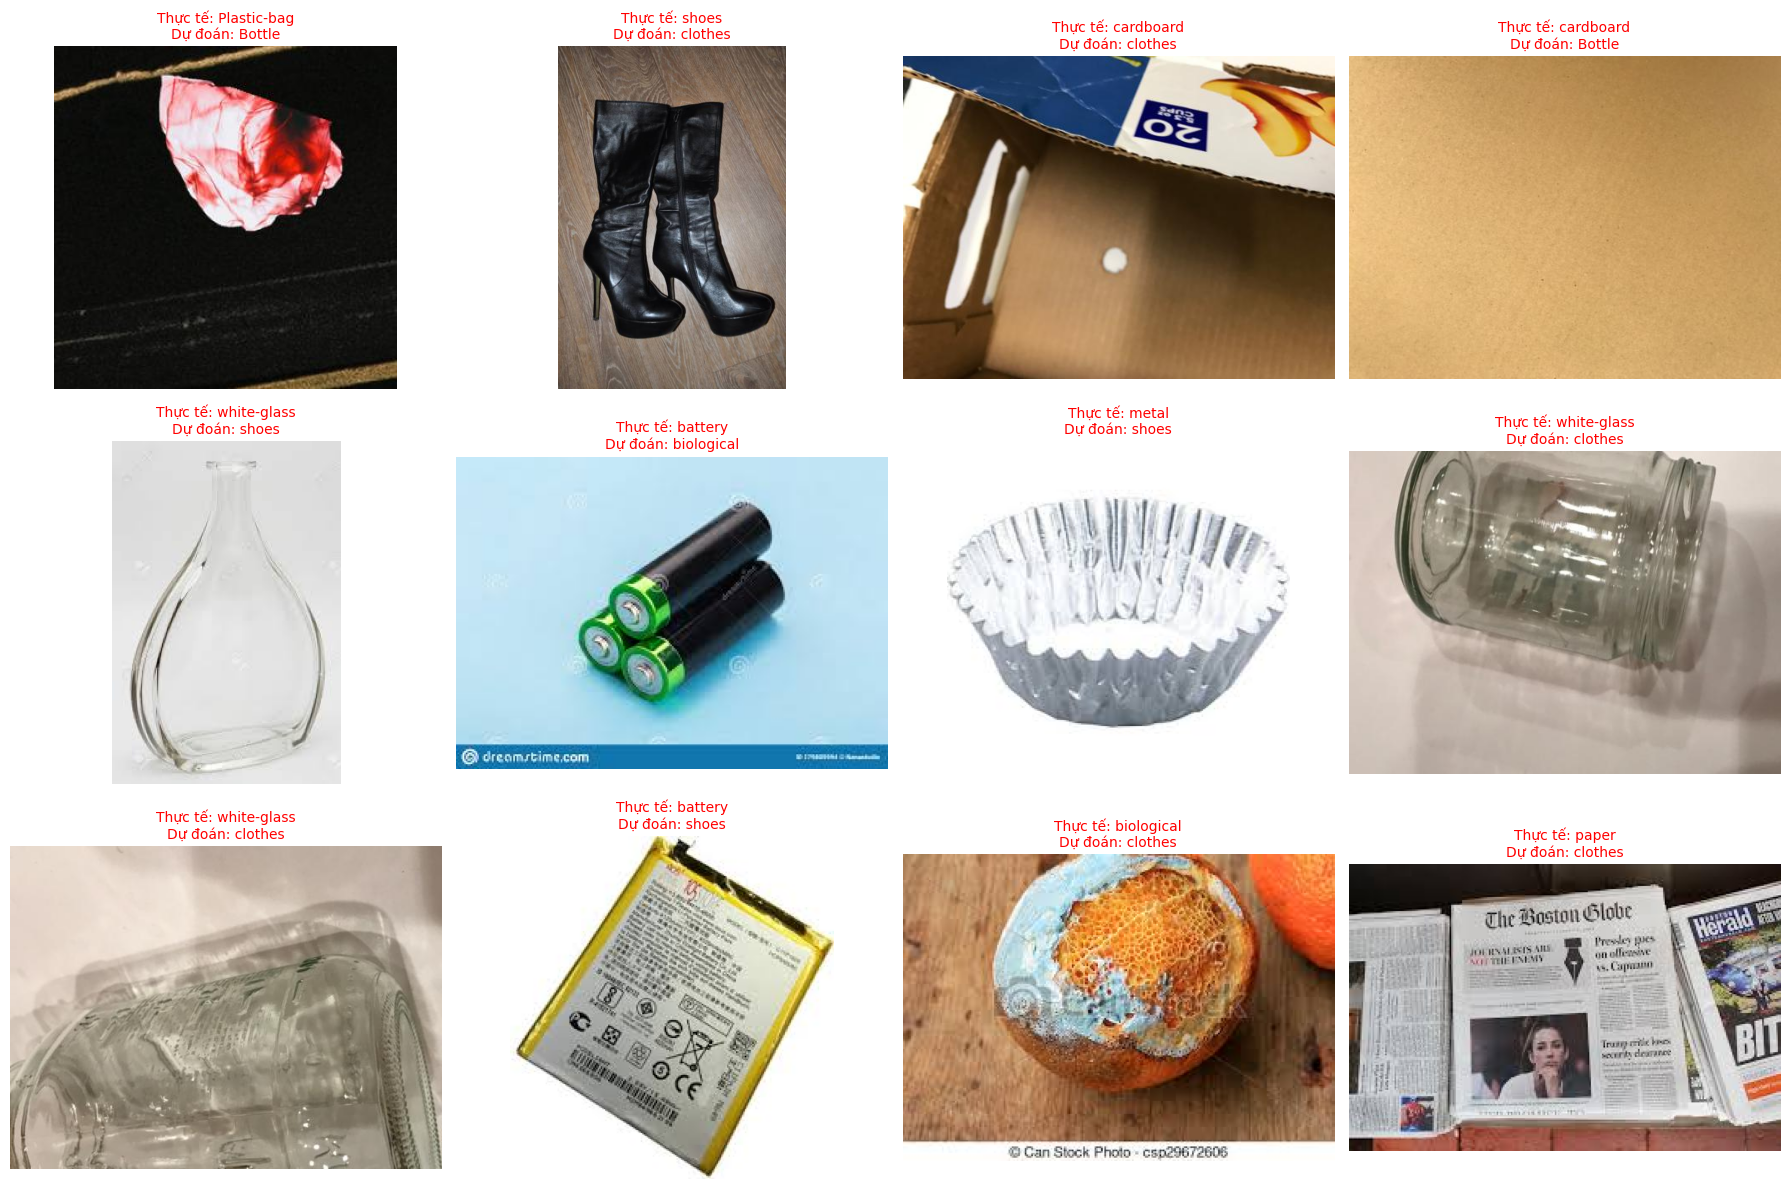

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán SAI
misclassified_mask = (y_test != y_pred_svm)
indices_in_test_set = np.where(misclassified_mask)[0]
num_misclassified = len(indices_in_test_set)

print(f"HIỂN THỊ ẢNH BỊ PHÂN LOẠI SAI NGẪU NHIÊN (Tổng: {num_misclassified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị (Ví dụ: 12 ảnh)
num_to_display = min(12, num_misclassified)


# Lấy ngẫu nhiên 'num_to_display' chỉ mục từ 'indices_in_test_set'
random_misclassified_indices = np.random.choice(
    indices_in_test_set, 
    size=num_to_display, 
    replace=False # Đảm bảo không chọn trùng lặp
)
# =========================================================

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten() 

for i in range(num_to_display):
    # Lấy chỉ mục đã chọn ngẫu nhiên
    test_idx = random_misclassified_indices[i] 
    
    # Lấy thông tin nhãn
    true_label = y_test[test_idx]
    pred_label = y_pred_svm[test_idx]
    true_class_name = classes[true_label]
    predicted_class_name = classes[pred_label]
    
    # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
    image_path = paths_test[test_idx] 
    image = cv2.imread(image_path)
    
    if image is None:
        image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
        title_color = 'gray'
    else:
        # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        title_color = 'red'
    
    # Hiển thị ảnh
    axes[i].imshow(image_rgb)
    axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                      color=title_color, fontsize=10)
    axes[i].axis('off')

# Ẩn các ô trống
for j in range(num_to_display, 12):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

HIỂN THỊ ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN (Tổng: 2133 ảnh)


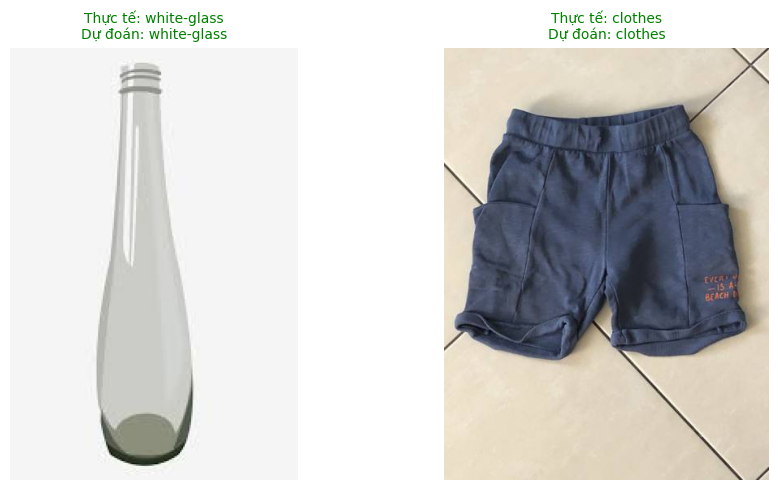

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 

# 1. Tìm các chỉ mục (indices) nơi dự đoán ĐÚNG
correctly_classified_mask = (y_test == y_pred_svm)
indices_in_test_set = np.where(correctly_classified_mask)[0]
num_correctly_classified = len(indices_in_test_set)

print(f"HIỂN THỊ ẢNH ĐƯỢC PHÂN LOẠI ĐÚNG NGẪU NHIÊN (Tổng: {num_correctly_classified} ảnh)")

# Chọn số lượng ảnh muốn hiển thị
num_to_display = min(2, num_correctly_classified) # Chỉ hiển thị 2 ảnh như yêu cầu

# Lấy ngẫu nhiên 'num_to_display' chỉ mục
if num_correctly_classified > 0:
    random_correct_indices = np.random.choice(
        indices_in_test_set, 
        size=num_to_display, 
        replace=False # Đảm bảo không chọn trùng lặp
    )
else:
    print("Không tìm thấy mẫu nào được phân loại đúng.")
    exit() # Thoát nếu không có mẫu nào đúng
# =========================================================

# Khởi tạo figure để hiển thị 2 ảnh
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
# Đảm bảo axes là một mảng nếu chỉ có 1 ảnh (trường hợp num_to_display = 1)
if num_to_display == 1:
    axes = [axes] 

for i in range(num_to_display):
    # Lấy chỉ mục đã chọn ngẫu nhiên
    test_idx = random_correct_indices[i] 
    
    # Lấy thông tin nhãn
    true_label = y_test[test_idx]
    pred_label = y_pred_svm[test_idx]
    true_class_name = classes[true_label]
    predicted_class_name = classes[pred_label]
    
    # *** ĐỌC ẢNH GỐC TỪ ĐƯỜNG DẪN paths_test ***
    image_path = paths_test[test_idx] 
    image = cv2.imread(image_path)
    
    if image is None:
        image_rgb = np.zeros((128, 128, 3), dtype=np.uint8) 
        title_color = 'gray'
    else:
        # Chuyển từ BGR (OpenCV) sang RGB (Matplotlib)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        # Vì dự đoán đúng, chúng ta dùng màu xanh lá
        title_color = 'green' 
    
    # Hiển thị ảnh
    axes[i].imshow(image_rgb)
    axes[i].set_title(f"Thực tế: {true_class_name}\nDự đoán: {predicted_class_name}", 
                      color=title_color, fontsize=10)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

MA TRẬN NHẦM LẪN (CONFUSION MATRIX)


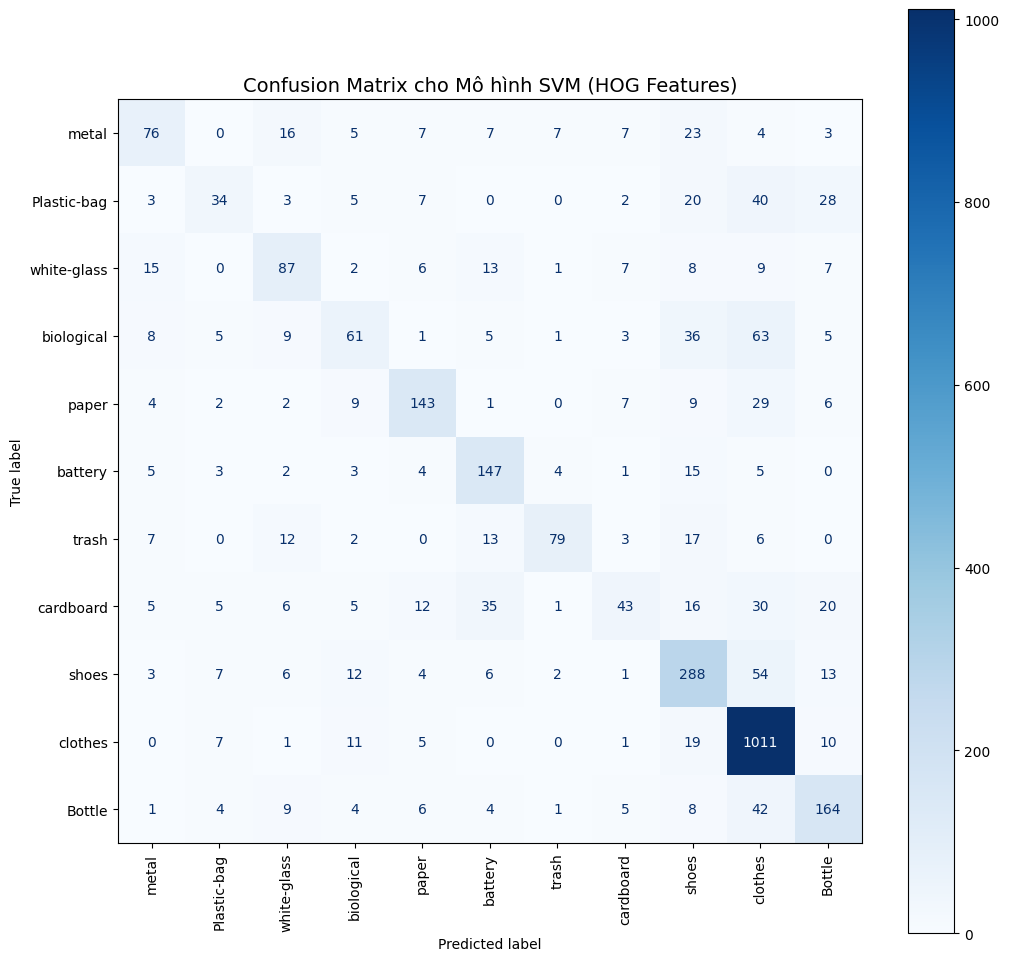


 Ma trận nhầm lẫn đã được lưu thành công dưới dạng file: confusion_matrix_svm.png


In [17]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# --- BƯỚC QUAN TRỌNG: Tính toán cm trước khi hiển thị ---
cm = confusion_matrix(y_test, y_pred_svm)

# 2. Trực quan hóa Ma trận nhầm lẫn
print("="*60)
print("MA TRẬN NHẦM LẪN (CONFUSION MATRIX)")
print("="*60)

# Sử dụng subplots để kiểm soát kích thước biểu đồ tốt hơn
fig, ax = plt.subplots(figsize=(12, 12)) 

# Truyền 'cm' và 'classes' vào đây
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)

# Hiển thị ma trận
disp.plot(cmap=plt.cm.Blues, xticks_rotation='vertical', ax=ax)
plt.title('Confusion Matrix cho Mô hình SVM (HOG Features)', fontsize=14)

file_name = "confusion_matrix_svm.png" 
plt.savefig(file_name, bbox_inches='tight', dpi=300) 

plt.show() 

print(f"\n Ma trận nhầm lẫn đã được lưu thành công dưới dạng file: {file_name}")